In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv(r"C:\Users\carol\OneDrive\Desktop\Carolina\Carolina\raw\consumoshorariocodigopostal3781a4420.csv", sep=';', encoding='utf-8')

In [41]:
df.columns.tolist()

['Data/Hora',
 'Código Postal',
 'Energia ativa (kWh)',
 'Data',
 'Hora',
 'Código Postal 4 Dígitos',
 'Código Postal 3 Dígitos']

In [42]:
df.columns = df.columns.str.strip()

In [43]:
print(df.dtypes)

Data/Hora                      str
Código Postal                  str
Energia ativa (kWh)        float64
Data                           str
Hora                           str
Código Postal 4 Dígitos      int64
Código Postal 3 Dígitos      int64
dtype: object


In [44]:
df_soma_consumos = df['Energia ativa (kWh)'].sum()
print(f"Soma total dos consumos: {df_soma_consumos} kWh")

Soma total dos consumos: 372467532.6572896 kWh


In [45]:
consumo_fev = 372467532.6572896
dias_fev = 29
consumo_diario_medio = consumo_fev / dias_fev

# Série anual através do mês de fevereiro

In [ ]:
#pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
import pandas as pd

# 1. Carregar o ficheiro saltando as 3 primeiras linhas de lixo (0, 1 e 2)
# Vamos ler a partir da linha 3, onde os dados realmente começam
path = r"C:\Users\carol\OneDrive\Desktop\Carolina\Milestone3\raw\E-REDES_Perfil_Consumo_2023.xlsx"
df = pd.read_excel(path, skiprows=3, header=None)

# 2. Atribuir os nomes corretos às colunas manualmente, baseando-se na estrutura que enviou
# Coluna 0: Data, Coluna 1: Dia, Coluna 2: Hora, Coluna 3: BTN A, Coluna 4: BTN B, Coluna 5: BTN C, Coluna 6: IP
df.columns = ['Data', 'Dia_Semana', 'Hora', 'BTN_A', 'BTN_B', 'BTN_C', 'IP']

# 3. Limpar a coluna 'Hora' (tratar o 24:00 se ele aparecer)
df['Hora'] = df['Hora'].astype(str).str.replace('24:00', '00:00')

# 4. Criar o índice Datetime
# Como a coluna 'Data' já parece vir como datetime do Excel, garantimos a conversão
df['datetime'] = pd.to_datetime(df['Data'].astype(str).str.split(' ').str[0] + ' ' + df['Hora'])
df = df.set_index('datetime')

# 5. Calcular os Coeficientes para o BTN C
# BTN C está na coluna que nomeámos acima
consumo_mensal = df['BTN_C'].resample('MS').sum()

# 6. Normalizar para Coeficientes (Soma = 1.0)
coef_mensais = consumo_mensal / consumo_mensal.sum()

# 7. Formatar e imprimir
meses_nomes = ['Jan','Fev','Mar','Abr','Mai','Jun', 'Jul','Ago','Set','Out','Nov','Dez']
if len(coef_mensais) == 12:
    coef_mensais.index = meses_nomes

print("\n--- Coeficientes Mensais E-Redes (Estrutura Corrigida) ---")
print(coef_mensais.round(4))
print(f"\nSoma total: {coef_mensais.sum():.4f}")

# Extra: Mês de maior consumo
print(f"Mês de maior consumo teórico: {coef_mensais.idxmax()}")


--- Coeficientes Mensais E-Redes (Estrutura Corrigida) ---
Jan    0.1076
Fev    0.0899
Mar    0.0873
Abr    0.0766
Mai    0.0734
Jun    0.0721
Jul    0.0789
Ago      0.08
Set    0.0734
Out    0.0754
Nov    0.0828
Dez    0.1027
Name: BTN_C, dtype: object

Soma total: 1.0000
Mês de maior consumo teórico: Jan


In [48]:
# Consumo observado em fevereiro 2024 no teu CP7 (em kWh)
consumo_fevereiro = 372467532.6572896

# Coeficiente de fevereiro (mês 2) do perfil E-Redes
coef_fev = coef_mensais['Fev']

# Consumo anual estimado
consumo_anual_estimado = consumo_fevereiro / coef_fev

# Distribuição pelos 12 meses
consumo_por_mes = consumo_anual_estimado * coef_mensais

print(f"Consumo anual estimado: {consumo_anual_estimado:.0f} kWh")
print("\nDistribuição mensal estimada:")
print(consumo_por_mes.round(0))

Consumo anual estimado: 4142999095 kWh

Distribuição mensal estimada:
Jan    445873147.0
Fev    372467533.0
Mar    361785709.0
Abr    317382743.0
Mai    304097778.0
Jun    298631417.0
Jul    326734142.0
Ago    331306162.0
Set    303917052.0
Out    312280946.0
Nov    342908497.0
Dez    425613969.0
Name: BTN_C, dtype: object


In [49]:
consumo_por_mes = consumo_por_mes.astype(float)

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

coefs = pd.Series({
    'Jan': 0.1076, 'Fev': 0.0899, 'Mar': 0.0873, 'Abr': 0.0766,
    'Mai': 0.0734, 'Jun': 0.0721, 'Jul': 0.0789, 'Ago': 0.0800,
    'Set': 0.0734, 'Out': 0.0754, 'Nov': 0.0828, 'Dez': 0.1027
})

# Verificações básicas
print(f"Soma: {coefs.sum():.4f}")                          # deve ser 1.0
print(f"Rácio pico/vale: {coefs.max()/coefs.min():.3f}x") # Jan/Jun ≈ 1.49x
print(f"Amplitude: {(coefs.max()-coefs.min())*100:.2f} pp")

# Aplicar ao teu consumo de fevereiro
consumo_fev = 372467532.6572896  # kWh observados em fevereiro 2024

consumo_anual = consumo_fev / coefs['Fev']
consumo_mensal_estimado = consumo_anual * coefs

print(f"\nConsumo anual estimado: {consumo_anual:,.1f} kWh")
print("\nDistribuição mensal (kWh):")
print(consumo_mensal_estimado.round(1).to_string())

Soma: 1.0001
Rácio pico/vale: 1.492x
Amplitude: 3.55 pp

Consumo anual estimado: 4,143,131,620.2 kWh

Distribuição mensal (kWh):
Jan    445800962.3
Fev    372467532.7
Mar    361695390.4
Abr    317363882.1
Mai    304105860.9
Jun    298719789.8
Jul    326893084.8
Ago    331450529.6
Set    304105860.9
Out    312392124.2
Nov    343051298.2
Dez    425499617.4


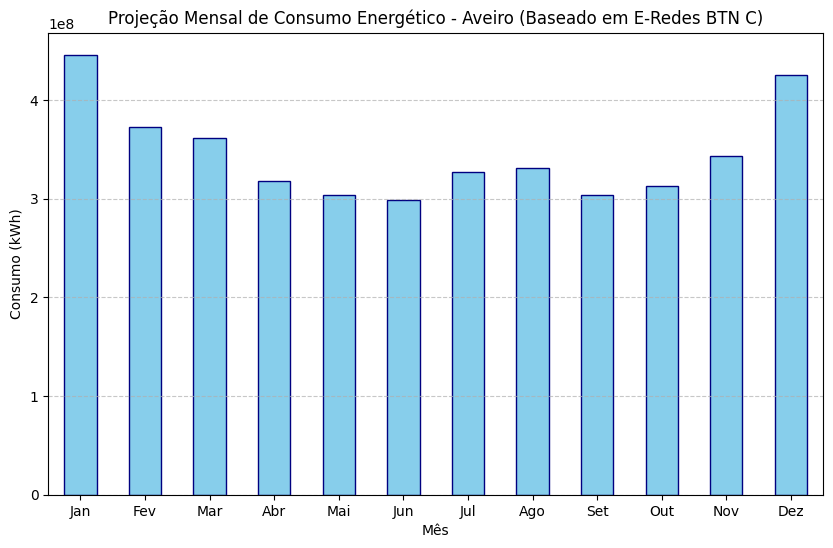

In [51]:
plt.figure(figsize=(10, 6))
consumo_mensal_estimado.plot(kind='bar', color='skyblue', edgecolor='navy')
plt.title('Projeção Mensal de Consumo Energético - Aveiro (Baseado em E-Redes BTN C)')
plt.ylabel('Consumo (kWh)')
plt.xlabel('Mês')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()

In [55]:
perfil_analise = (
    pd.to_numeric(df['BTN_C'], errors='coerce') / 1e6
).dropna().reset_index(drop=True)

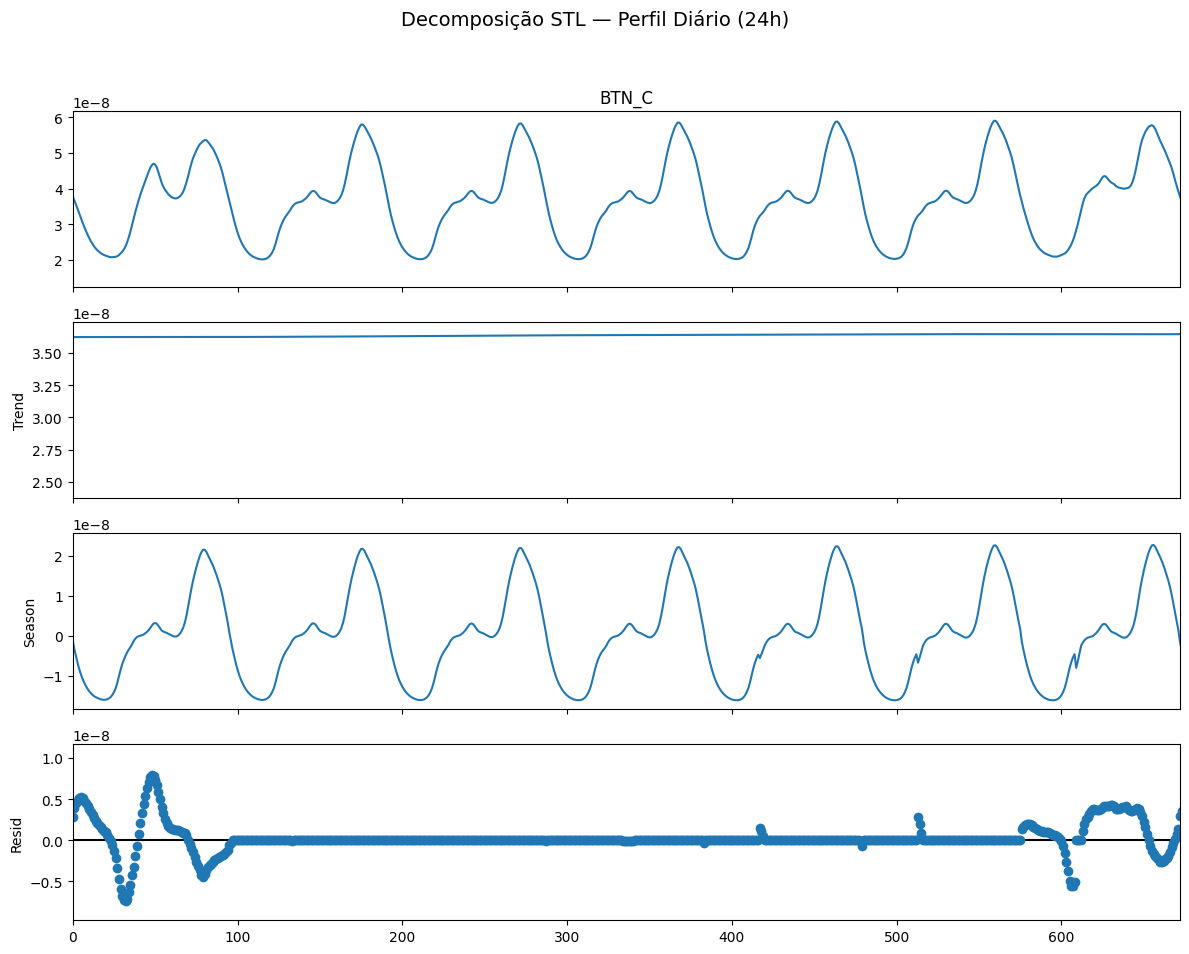

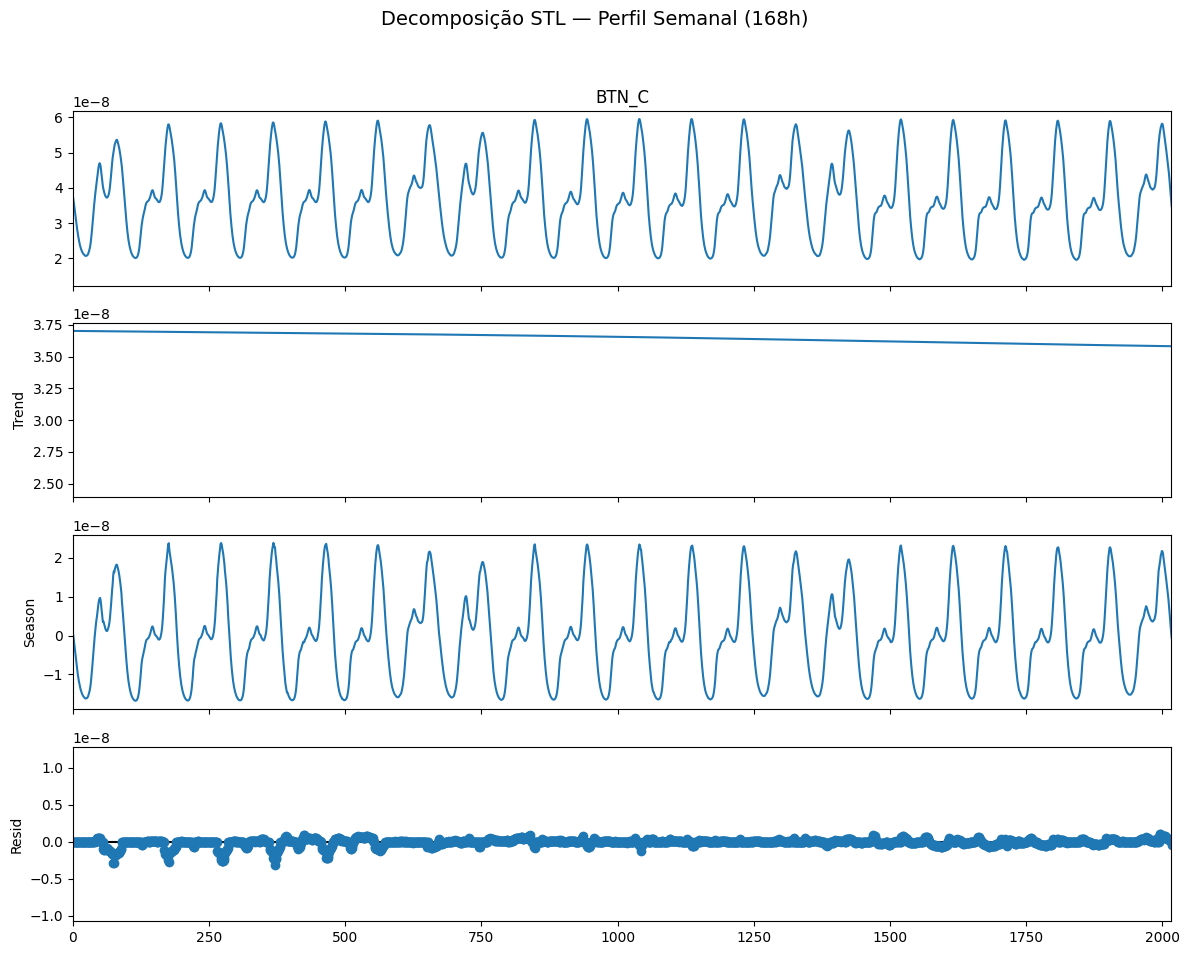


--- Estatísticas das Componentes (GWh) ---
             Componente  Máximo  Mínimo  Amplitude
0   Sazonalidade Diária     0.0    -0.0        0.0
1  Sazonalidade Semanal     0.0    -0.0        0.0


In [ ]:
import pandas as pd
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt



# 1. Preparação dos dados
perfil_analise = (
    pd.to_numeric(df['BTN_C'], errors='coerce') / 1e6
).dropna().reset_index(drop=True)

# 2. STL diária
stl_diario = STL(perfil_analise, period=96, robust=True)
res_diario = stl_diario.fit()

plt.rcParams['figure.figsize'] = (12, 10)

fig1 = res_diario.plot()
plt.suptitle('Decomposição STL — Perfil Diário (24h)', fontsize=14)

# Mostrar apenas 7 dias
for ax in fig1.get_axes():
    ax.set_xlim(0, 96 * 7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. STL semanal
stl_semanal = STL(perfil_analise, period=672, robust=True)
res_semanal = stl_semanal.fit()

fig2 = res_semanal.plot()
plt.suptitle('Decomposição STL — Perfil Semanal (168h)', fontsize=14)

# Mostrar apenas 3 semanas
for ax in fig2.get_axes():
    ax.set_xlim(0, 672 * 3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4. Estatísticas
print("\n--- Estatísticas das Componentes (GWh) ---")

stats = pd.DataFrame({
    'Componente': ['Sazonalidade Diária', 'Sazonalidade Semanal'],
    'Máximo': [res_diario.seasonal.max(), res_semanal.seasonal.max()],
    'Mínimo': [res_diario.seasonal.min(), res_semanal.seasonal.min()],
    'Amplitude': [
        res_diario.seasonal.max() - res_diario.seasonal.min(),
        res_semanal.seasonal.max() - res_semanal.seasonal.min()
    ]
})

print(stats.round(6))

Coluna utilizada: BTN_C
Média da série: 118.2367 GWh


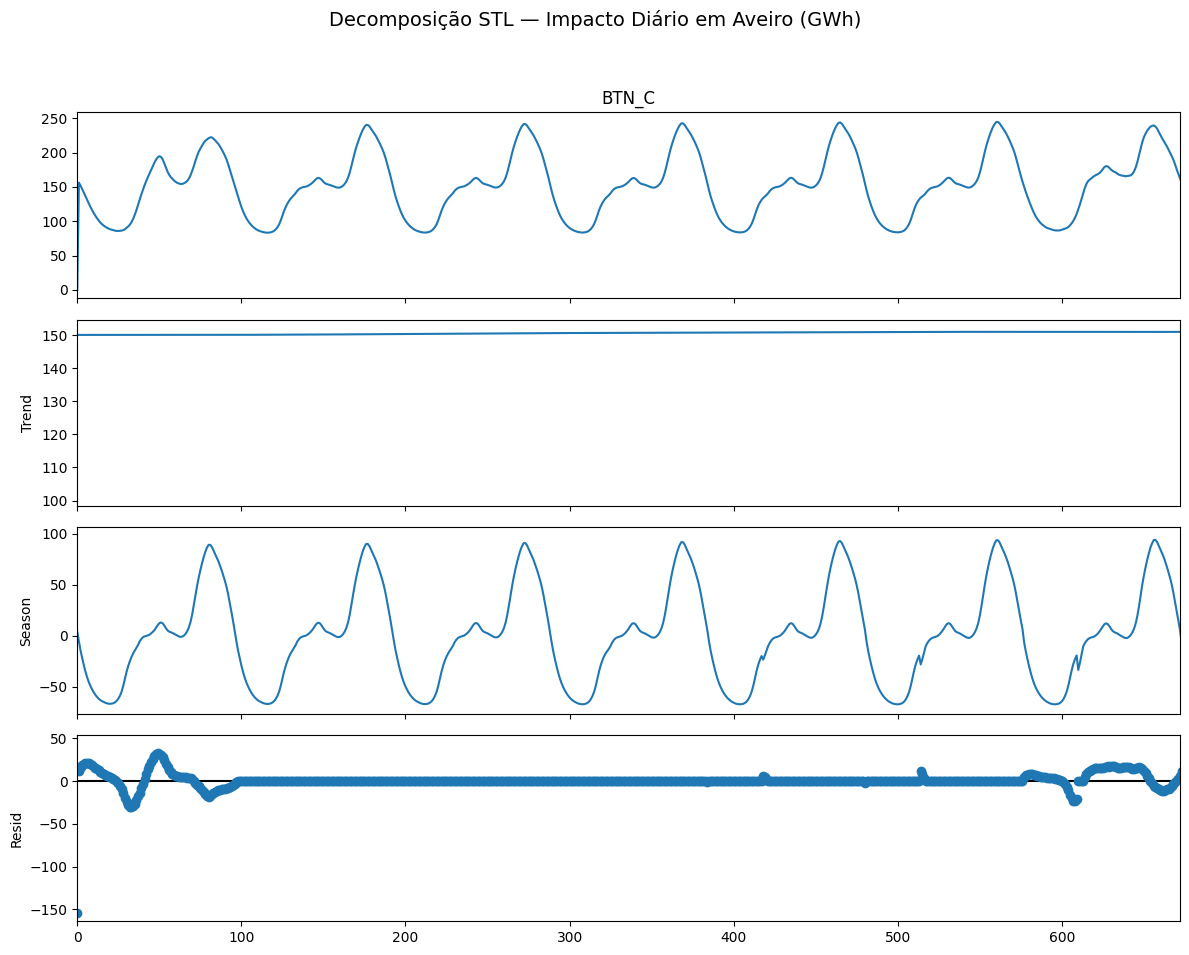

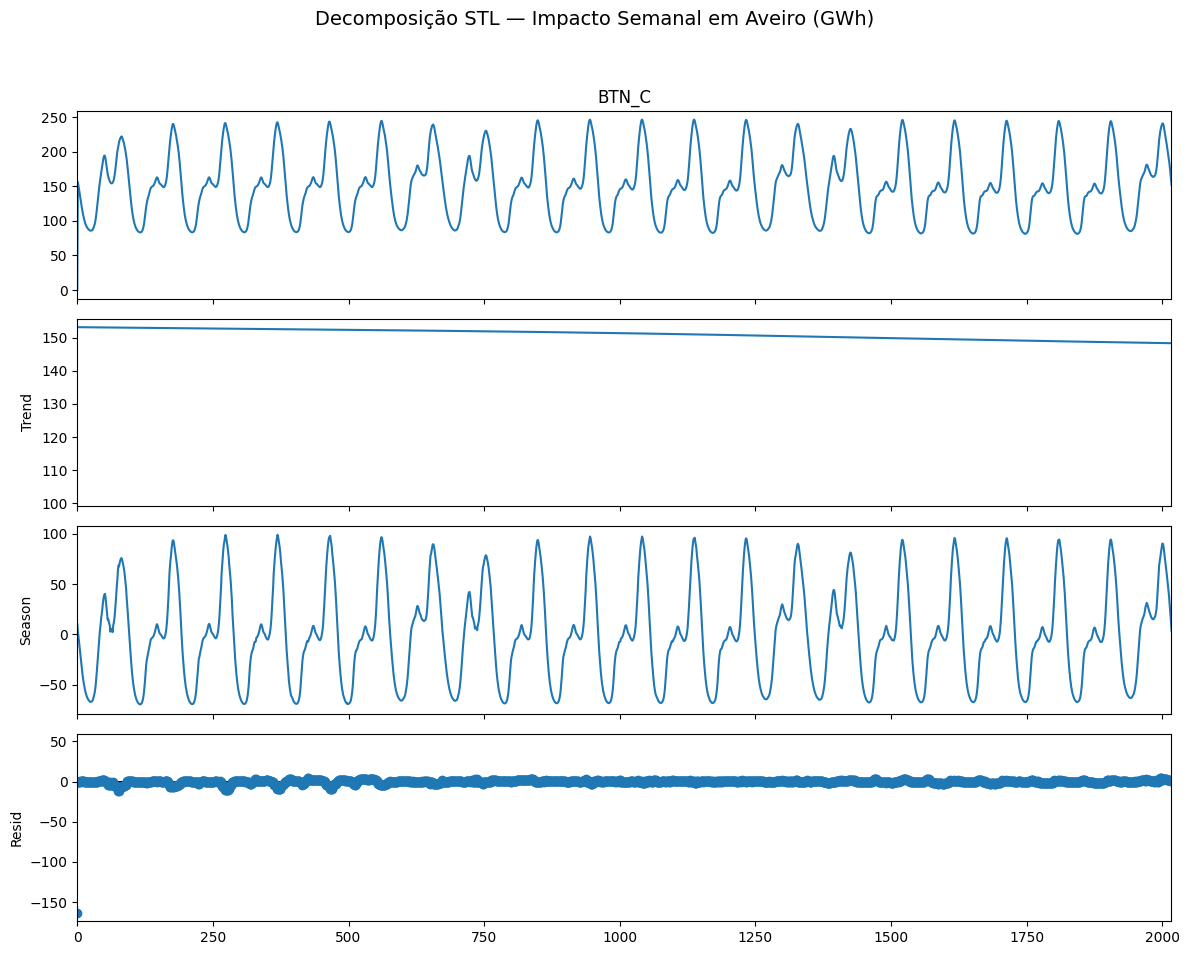


--- Estatísticas das Componentes de Carga (GWh) ---
             Componente  Máximo (GWh)  Mínimo (GWh)  Amplitude (GWh)
0   Sazonalidade Diária       97.9586      -67.9506         165.9092
1  Sazonalidade Semanal       99.0433      -70.3970         169.4402


In [62]:
import pandas as pd
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# =========================================================
# 1. CONFIGURAÇÃO DO CONSUMO TOTAL ANUAL (kWh)
# =========================================================

consumo_anual_total_kwh = 4143131620.2

# =========================================================
# 2. IDENTIFICAR A COLUNA BTN C
# =========================================================

coluna_perfil = [
    c for c in df.columns
    if 'BTN' in str(c).upper() and 'C' in str(c).upper()
]

if not coluna_perfil:
    raise KeyError("Coluna BTN C não encontrada no DataFrame.")

perfil_real = coluna_perfil[0]

print(f"Coluna utilizada: {perfil_real}")

# =========================================================
# 3. LIMPEZA E PREPARAÇÃO DOS DADOS
# =========================================================

# Converter para numérico
perfil_series = pd.to_numeric(
    df[perfil_real],
    errors='coerce'
)

# Interpolar valores em falta
perfil_series = perfil_series.interpolate(method='linear')

# Substituir NaN restantes por 0
perfil_series = perfil_series.fillna(0)

# Reset do índice para evitar erros no plot STL
perfil_series = perfil_series.reset_index(drop=True)

# =========================================================
# 4. ESCALONAMENTO PARA GWh REAIS
# =========================================================

perfil_analise = (
    perfil_series * consumo_anual_total_kwh
) / 1e6

print(f"Média da série: {perfil_analise.mean():.4f} GWh")

# =========================================================
# 5. DECOMPOSIÇÃO STL DIÁRIA
# 96 intervalos de 15 min = 24h
# =========================================================

stl_diario = STL(
    perfil_analise,
    period=96,
    robust=True
)

res_diario = stl_diario.fit()

# =========================================================
# 6. PLOT DIÁRIO
# =========================================================

plt.rcParams['figure.figsize'] = (12, 10)

fig1 = res_diario.plot()

plt.suptitle(
    'Decomposição STL — Impacto Diário em Aveiro (GWh)',
    fontsize=14
)

# Mostrar apenas os primeiros 7 dias
for ax in fig1.get_axes():
    ax.set_xlim(0, 96 * 7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# =========================================================
# 7. DECOMPOSIÇÃO STL SEMANAL
# 672 intervalos de 15 min = 168h
# =========================================================

stl_semanal = STL(
    perfil_analise,
    period=672,
    robust=True
)

res_semanal = stl_semanal.fit()

# =========================================================
# 8. PLOT SEMANAL
# =========================================================

fig2 = res_semanal.plot()

plt.suptitle(
    'Decomposição STL — Impacto Semanal em Aveiro (GWh)',
    fontsize=14
)

# Mostrar apenas as primeiras 3 semanas
for ax in fig2.get_axes():
    ax.set_xlim(0, 672 * 3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# =========================================================
# 9. ESTATÍSTICAS DAS COMPONENTES
# =========================================================

print("\n--- Estatísticas das Componentes de Carga (GWh) ---")

stats = pd.DataFrame({
    'Componente': [
        'Sazonalidade Diária',
        'Sazonalidade Semanal'
    ],

    'Máximo (GWh)': [
        res_diario.seasonal.max(),
        res_semanal.seasonal.max()
    ],

    'Mínimo (GWh)': [
        res_diario.seasonal.min(),
        res_semanal.seasonal.min()
    ],

    'Amplitude (GWh)': [
        res_diario.seasonal.max() - res_diario.seasonal.min(),
        res_semanal.seasonal.max() - res_semanal.seasonal.min()
    ]
})

print(stats.round(4))

In [63]:
print(perfil_series.describe())

count    35041.000000
mean         0.028538
std          0.008884
min          0.000000
25%          0.021527
50%          0.028022
75%          0.033425
max          0.059515
Name: BTN_C, dtype: float64


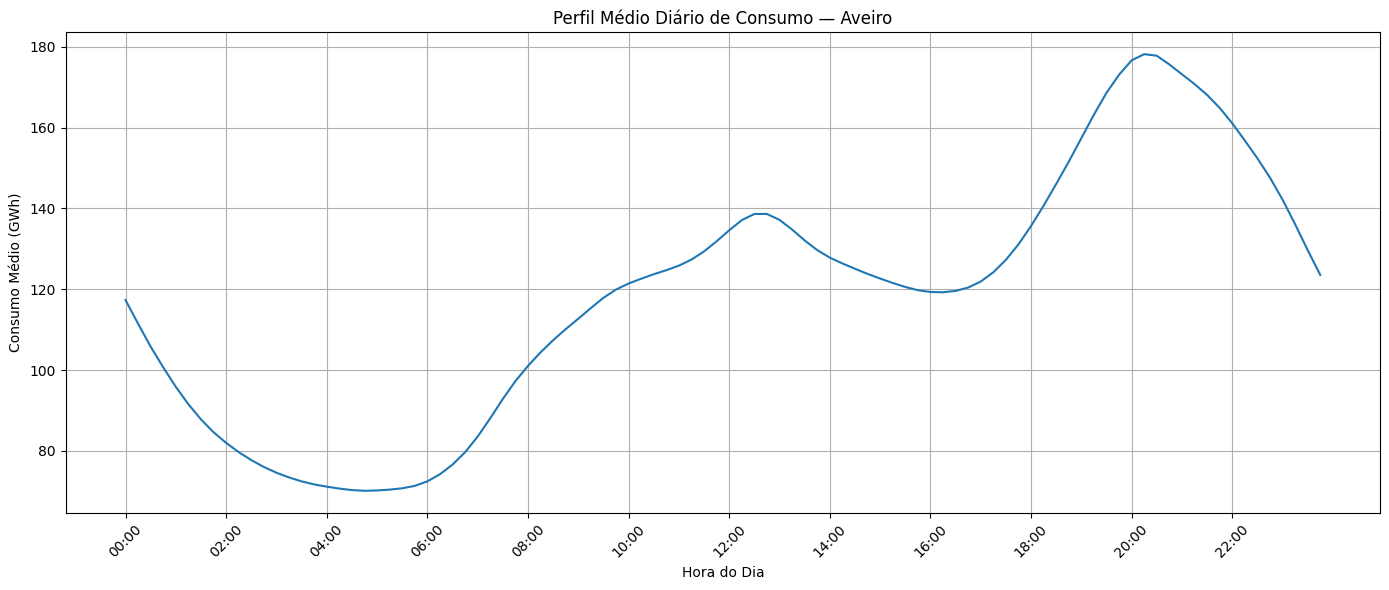

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. CRIAR DATETIME
# =========================================================

df['Datetime'] = pd.to_datetime(
    df['Data'].astype(str) + ' ' + df['Hora'].astype(str),
    errors='coerce'
)

# =========================================================
# 2. LIMPEZA
# =========================================================

df['BTN_C'] = pd.to_numeric(df['BTN_C'], errors='coerce')

df = df.dropna(subset=['Datetime', 'BTN_C'])

# =========================================================
# 3. CRIAR HORA DO DIA
# =========================================================

df['hora_dia'] = df['Datetime'].dt.strftime('%H:%M')

# =========================================================
# 4. PERFIL MÉDIO DIÁRIO
# =========================================================

perfil_medio = df.groupby('hora_dia')['BTN_C'].mean()

# =========================================================
# 5. ESCALONAMENTO PARA GWh REAIS
# =========================================================

consumo_anual_total_kwh = 4143131620.2

perfil_medio_gwh = (
    perfil_medio * consumo_anual_total_kwh
) / 1e6

# =========================================================
# 6. PLOT
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    perfil_medio_gwh.index,
    perfil_medio_gwh.values
)

plt.title('Perfil Médio Diário de Consumo — Aveiro')
plt.xlabel('Hora do Dia')
plt.ylabel('Consumo Médio (GWh)')

# Mostrar menos labels
plt.xticks(
    ticks=range(0, len(perfil_medio_gwh.index), 8),
    labels=perfil_medio_gwh.index[::8],
    rotation=45
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [83]:
df.columns.tolist()

['Data',
 'Dia_Semana',
 'Hora',
 'BTN_A',
 'BTN_B',
 'BTN_C',
 'IP',
 'Carga_MW',
 'Datetime',
 'hora_dia',
 'Hora_Int']

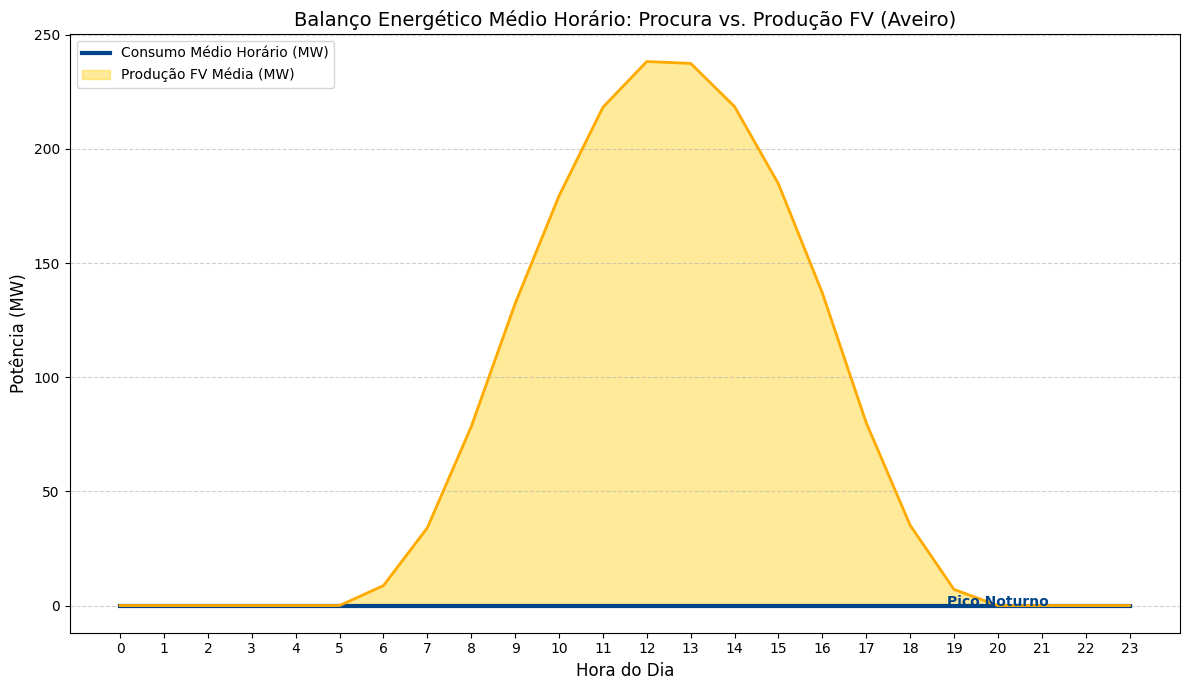

Potência Fotovoltaica Instalada considerada: 450 MWp
Pico Médio de Consumo: 0.00 MW
Pico Médio de Produção Solar: 238.24 MW


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#1. DEFINIÇÃO DE PARÂMETROS FOTOVOLTAICOS 
# Vamos assumir uma potência instalada para Aveiro. 
POTENCIA_INSTALADA_MWp = 450 
PR = 0.86 # Performance Ratio (perdas típicas de 14% no sistema)

# --- 2. IMPORTAR E LIMPAR PRODUÇÃO (TMY) ---
path_tmy = r"C:\Users\carol\OneDrive\Desktop\Carolina\Carolina\raw\tmy_40.593_-8.585_2005_2023.csv"
df_tmy = pd.read_csv(path_tmy, skiprows=17)
df_tmy.columns = df_tmy.columns.str.strip()

# Tratar datas e remover legenda do fim
df_tmy['datetime'] = pd.to_datetime(df_tmy['time(UTC)'], format='%Y%m%d:%H%M', errors='coerce')
df_tmy = df_tmy.dropna(subset=['datetime'])

# Criar coluna de Produção Estimada em MW
# Fórmula: (G(h) / 1000 W/m2) * MWp * Performance Ratio
df_tmy['Producao_MW'] = (df_tmy['G(h)'] / 1000) * POTENCIA_INSTALADA_MWp * PR

# 3. CRIAR CURVAS MÉDIAS HORÁRIAS

# A. Para a Produção (TMY)
# Extraímos a hora e calculamos a média para cada uma das 24 horas
df_tmy['Hora_Int'] = df_tmy['datetime'].dt.hour
media_producao = df_tmy.groupby('Hora_Int')['Producao_MW'].mean()

# B. Para o Consumo (df anterior)
# Primeiro garantimos que o consumo está em base horária (estava em 15 min)
# Se o teu df de consumo ainda não tiver a coluna 'Hora_Int', vamos criá-la:
df['Hora_Int'] = df.index.hour
media_consumo = df.groupby('Hora_Int')['Carga_MW'].mean()

# --- 4. SOBREPOSIÇÃO DOS GRÁFICOS ---

plt.figure(figsize=(12, 7))

# Plot do Consumo Médio
plt.plot(media_consumo.index, media_consumo.values, 
         label='Consumo Médio Horário (MW)', color='#004488', linewidth=3)

# Plot da Produção Média
plt.fill_between(media_producao.index, media_producao.values, 
                 label='Produção FV Média (MW)', color='#FFCC00', alpha=0.4)
plt.plot(media_producao.index, media_producao.values, color='#FFAA00', linewidth=2)

# Configurações do Gráfico
plt.title('Balanço Energético Médio Horário: Procura vs. Produção FV (Aveiro)', fontsize=14)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Potência (MW)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

# Adicionar sombra na área de défice (onde o consumo > produção)
plt.text(20, media_consumo.max(), 'Pico Noturno', color='#004488', fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

# --- 5. MÉTRICAS DE AUTOCONSUMO ---
print(f"Potência Fotovoltaica Instalada considerada: {POTENCIA_INSTALADA_MWp} MWp")
print(f"Pico Médio de Consumo: {media_consumo.max():.2f} MW")
print(f"Pico Médio de Produção Solar: {media_producao.max():.2f} MW")

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. CONFIGURAÇÃO E LIMPEZA ---
POTENCIA_INSTALADA_MWp = 450  
PR = 0.80 
consumo_anual_total_kwh = 4143131620.2 

# Garantir que a Carga_MW é numérica e sem vazios
# Se a coluna já existir, apenas garantimos que é float
df['Carga_MW'] = pd.to_numeric(df['Carga_MW'], errors='coerce').fillna(0)

# --- 2. MÉDIA HORÁRIA DE CONSUMO (Usando a tua coluna Hora_Int) ---
# Agrupamos pela coluna que já tens no teu df
media_consumo = df.groupby('Hora_Int')['Carga_MW'].mean()

# --- 3. MÉDIA HORÁRIA DE PRODUÇÃO (TMY) ---
# (Assumindo que já carregaste o df_tmy conforme os passos anteriores)
# Cálculo da produção em MW: (Irradiância / 1000) * Potência * Eficiência
df_tmy['Producao_MW'] = (df_tmy['G(h)'] / 1000) * POTENCIA_INSTALADA_MWp * PR

# Criar a média das 8760 horas do TMY para o "dia médio"
media_producao = df_tmy.groupby(df_tmy['time (UTC)'].dt.hour)['Producao_MW'].mean()

# --- 4. SOBREPOSIÇÃO DOS GRÁFICOS ---
plt.figure(figsize=(12, 7))

# Curva de Consumo (Procura)
plt.plot(media_consumo.index, media_consumo.values, 
         label='Consumo Médio (Procura em MW)', color='#004488', linewidth=3)

# Curva de Produção (Oferta)
plt.fill_between(media_producao.index, media_producao.values, 
                 label='Produção FV Média (Oferta em MW)', color='#FFCC00', alpha=0.4)
plt.plot(media_producao.index, media_producao.values, color='#FFAA00', linewidth=2)

# Formatação Académica
plt.title('Balanço Energético Médio Horário - Aveiro', fontsize=14)
plt.xlabel('Hora do Dia (h)', fontsize=12)
plt.ylabel('Potência (MW)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# --- 5. RESULTADOS FINAIS ---
print(f"--- Resultados para o Cenário de {POTENCIA_INSTALADA_MWp} MWp ---")
print(f"Pico Médio de Consumo: {media_consumo.max():.2f} MW")
print(f"Pico Médio de Produção: {media_producao.max():.2f} MW")
print(f"Cobertura Solar ao Meio-dia: {(media_producao[12]/media_consumo[12]*100):.1f}%")

KeyError: 'time (UTC)'